#Practical 3: PCA

In [20]:
import pandas as pd
import numpy as np

#here we are using inbuilt dataset of scikiy learn
from sklearn.datasets import load_breast_cancer

In [21]:
#instantiating
cancer = load_breast_cancer(as_frame=True)

In [22]:
#creating dataframe
df = cancer.frame

In [23]:
#Checking shape
print('Original Shape:',df.shape)

Original Shape: (569, 31)


In [24]:
#Input Features
X=df[cancer['feature_names']]
print('Inputs dataframe shape: ',X.shape)

Inputs dataframe shape:  (569, 30)


Now we will apply the first most step which is to standardize the data and for that, we will have to first calculate the mean and standard deviation of each feature in the feature space.

In [25]:
#Mean
X_mean = X.mean()

In [26]:
#Standard Deviation
X_std = X.std()

In [27]:
#Standardization
Z = (X-X_mean)/X_std


The covariance matrix helps us visualize how strong the dependency of two features is with each other in the feature space.

In [28]:
#Covariance
c = Z.cov()

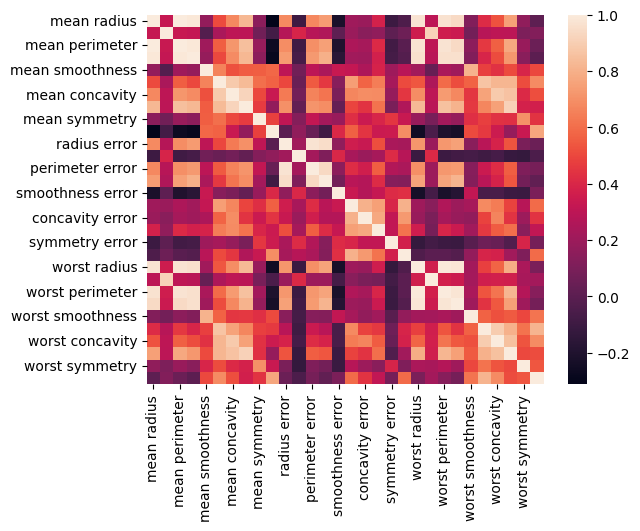

In [29]:
#Plotting the covariance matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(c)
plt.show()

Now we will compute the eigenvectors and eigenvalues for our feature space which serve a great purpose in identifying the principal components for our feature space.

In [30]:
#Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(c)
print('Eigenvalues:',eigenvalues)
print('Eigenvalues.shape:',eigenvalues.shape)
print('Eigenvectors.shape:',eigenvectors.shape)

Eigenvalues: [1.32816077e+01 5.69135461e+00 2.81794898e+00 1.98064047e+00
 1.64873055e+00 1.20735661e+00 6.75220114e-01 4.76617140e-01
 4.16894812e-01 3.50693457e-01 2.93915696e-01 2.61161370e-01
 2.41357496e-01 1.57009724e-01 9.41349650e-02 7.98628010e-02
 5.93990378e-02 5.26187835e-02 4.94775918e-02 1.33044823e-04
 7.48803097e-04 1.58933787e-03 6.90046388e-03 8.17763986e-03
 1.54812714e-02 1.80550070e-02 2.43408378e-02 2.74394025e-02
 3.11594025e-02 2.99728939e-02]
Eigenvalues.shape: (30,)
Eigenvectors.shape: (30, 30)


Sort the eigenvalues in descending order and sort the corresponding eigenvectors accordingly.

In [31]:
#Index the eigenvalues in descending order
idx = eigenvalues.argsort()[::-1]

In [32]:
#Sort the eigenvalues in descening order
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

Explained variance is the term that gives us an idea of the amount of the total variance which has been retained by selecting the principal components instead of the original feature space

In [35]:
harry_explained_variance = np.cumsum(eigenvalues)/eigenvalues.sum()
harry_explained_variance

array([0.44272026, 0.63243208, 0.72636371, 0.79238506, 0.84734274,
       0.88758796, 0.9100953 , 0.92598254, 0.93987903, 0.95156881,
       0.961366  , 0.97007138, 0.97811663, 0.98335029, 0.98648812,
       0.98915022, 0.99113018, 0.99288414, 0.9945334 , 0.99557204,
       0.99657114, 0.99748579, 0.99829715, 0.99889898, 0.99941502,
       0.99968761, 0.99991763, 0.99997061, 0.99999557, 1.        ])

Determin the **NUMBER OF PRINCIPAL COMPONENTS**
Here we can either consider the number of principal components of any value fo our choice or by limiting
the explained variance. Here I am considering explained variance more than equal to 50%. Let’s check how many principal components come into this.
n_components = np.argmax(explained_var >= 0.50) + 1
n_components

     

In [36]:
n_components = np.argmax(harry_explained_variance >= 0.50) + 1
n_components

np.int64(2)

Project the Data onto the Selected Principal Components

Find the projection matrix, It is a matrix of eigenvectors corresponding to the largest eigenvalues of the covariance matrix of the data. it projects the high-dimensional dataset onto a lower-dimensional subspace

The eigenvectors of the covariance matrix of the data are referred to as the principal axes of the data, and the projection of the data instances onto these principal axes are called the principal components.

In [37]:
#PCA Component or Unit Matrix
u = eigenvectors[:,:n_components]
pca_component = pd.DataFrame(u, index = cancer['feature_names'], columns=['PC1','PC2'])

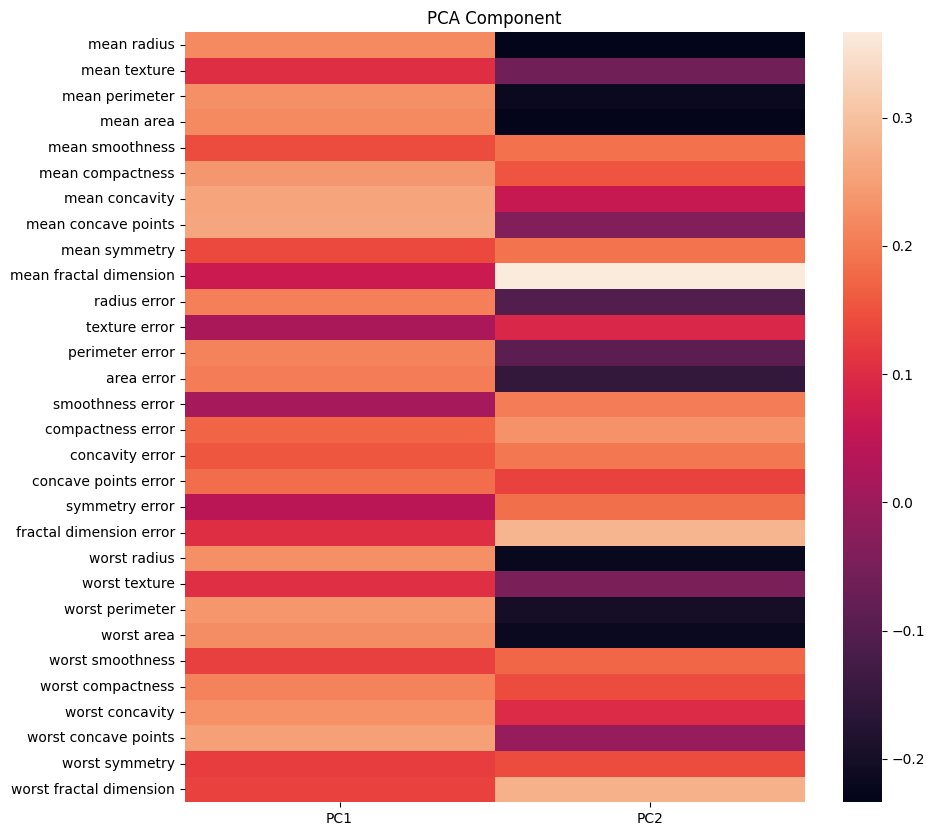

In [38]:
#Plotting Heatmap
plt.figure(figsize=(10,10))
sns.heatmap(pca_component)
plt.title('PCA Component')
plt.show()

In [39]:
#Matrix multiplication or dot product
Z_pca = Z @ pca_component

In [40]:
#Rename the columns name
Z_pca.rename({'PC1':'PCA1','PC2':'PCA2'}, axis = 1, inplace = True)
print(Z_pca)

          PCA1       PCA2
0     9.184755   1.946870
1     2.385703  -3.764859
2     5.728855  -1.074229
3     7.116691  10.266556
4     3.931842  -1.946359
..         ...        ...
564   6.433655  -3.573673
565   3.790048  -3.580897
566   1.255075  -1.900624
567  10.365673   1.670540
568  -5.470430  -0.670047

[569 rows x 2 columns]


#PCA using Sklearn

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(Z)
X_PCA = pca.transform(Z)

In [42]:
#Create the dataframe
df_pca1 = pd.DataFrame(X_PCA, columns = ['PCA1','PCA2'])
print(df_pca1)

          PCA1       PCA2
0     9.184755   1.946870
1     2.385703  -3.764859
2     5.728855  -1.074229
3     7.116691  10.266556
4     3.931842  -1.946359
..         ...        ...
564   6.433655  -3.573673
565   3.790048  -3.580897
566   1.255075  -1.900624
567  10.365673   1.670540
568  -5.470430  -0.670047

[569 rows x 2 columns]


 We can match from the above Z_pca result from it is exactly the same values.

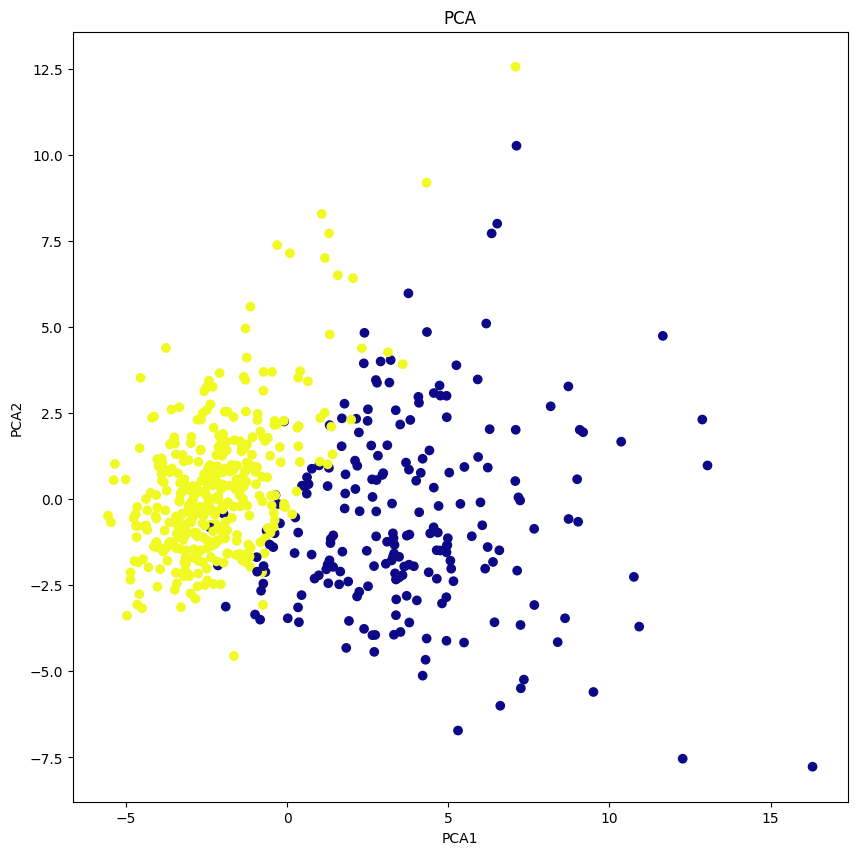

In [44]:
#giving a larger plot
plt.figure(figsize=(10,10))
plt.scatter(df_pca1['PCA1'],df_pca1['PCA2'], c=cancer['target'],cmap='plasma')
plt.title('PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [45]:
pca.components_

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])